# ScoutRAG — Constrained Hybrid Retrieval for Football Player Scouting
**CS455 — Large Language Models · Standard Track**  
Çubukçu · Özer · Yılmaz

ScoutRAG is a **retrieval-augmented scouting assistant**. A user writes a natural-language
query ("a clinical, left-footed striker under 21, valued below €10M") and the system returns
the players that match, ranked best→worst.

The system is a **constrained hybrid retrieval pipeline over structured and semantic player
attributes**: precise constraints are enforced by strict symbolic filtering, fuzzy scouting
language is mapped to attribute constraints by a local LLM, and an optional semantic stage
re-ranks within the filtered pool. A post-generation **grounding-verification** step checks
that any numbers cited in a generated report actually appear in the retrieved rows.

> **Dataset honesty note.** The data is a Football Manager 2024 export. Every attribute is a
> *designer-set game value on a 1–20 scale*, **not** real-world scouting data. We treat it
> strictly as a **synthetic / prototype tabular dataset** for validating the retrieval and
> grounding machinery. No claim is made that these ratings reflect real player ability.

This notebook runs **fully locally** (no Google Drive, no paid APIs). The optional LLM step
uses a local **Ollama** model; everything degrades gracefully if it is not running.

## 0 · Environment & local setup
Run from the project root so the `scoutrag` package is importable. Hardware: any Apple-Silicon
Mac with 16 GB RAM is comfortable. The embedding model runs on CPU/MPS; the optional LLM needs
Ollama (`brew install ollama && ollama pull llama3.1`).

In [1]:
# Install once if needed (uncomment):
# %pip install -r requirements.txt
import os, sys, json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 160)

# Make the local scoutrag package importable
sys.path.insert(0, os.path.abspath("."))
from scoutrag import (load_and_clean, build_profiles, align_embeddings,
                      parse_query, structured_filter, rank_players, search,
                      ATTR_READABLE, OUTFIELD_ATTR_COLS, GK_ONLY_COLS, NO_MATCH_MESSAGE)
from scoutrag import llm as scout_llm

CSV_PATH = "fmdata24llm.csv"
PKL_PATH = "player_embeddings.pkl"
GREEN = "#1fae7a"
plt.rcParams.update({"axes.grid": True, "grid.alpha": .25, "figure.facecolor": "white"})
print("imports OK")

imports OK


## 1 · Load & clean the dataset
The `Name` field packs the nationality (`"Lionel Messi - Argentinian"`) and `Club` packs the
league. Money and weight are messy strings. The FM24 export also contains ~1,900 empty engine
slots whose name is the placeholder `"- -"`.

**Cleaning rule (per project spec):** any row whose player name is *missing, empty, whitespace,
invisible, or contains no alphabetic character* is removed.

In [2]:
df = load_and_clean(CSV_PATH)            # strict name cleaning happens here
df = build_profiles(df)                  # adds 'profile' text + 'Overall' + 'is_GK'
print(f"Clean dataset: {df.shape[0]:,} players x {df.shape[1]} columns")
df[["Player_Name","Nationality","Age","Position","Club_Name","League",
    "Value_EUR","Wage_EUR_pm","Foot","Overall"]].head()

Removed 1,895 rows with missing/invalid names (42,583 -> 40,688 players).


Clean dataset: 40,688 players x 75 columns


,Player_Name,Nationality,Age,Position,Club_Name,League,Value_EUR,Wage_EUR_pm,Foot,Overall
0,Lionel Messi,Argentinian,36,"AM (RC), ST (C)",Inter Miami,Major League Soccer,NaN,1591000.0,Left,13.972222
1,Kevin De Bruyne,Belgian,32,"M (RLC), AM (C)",Man City,English Premier Division,NaN,1718000.0,Right,14.305556
2,Kylian Mbappé,French,24,"AM (RL), ST (C)",Paris SG,Ligue 1 Uber Eats,220000000.0,4488000.0,Right,13.277778
3,Rodri,Spanish,27,"D (C), DM, M (C)",Man City,English Premier Division,322000000.0,834000.0,Right,13.722222
4,Erling Haaland,Norwegian,22,ST (C),Man City,English Premier Division,NaN,1718000.0,Left,14.388889


### What cleaning removed
A quick before/after to document exactly which rows were dropped and why.

In [3]:
raw = pd.read_csv(CSV_PATH); raw.columns=[x.lstrip('\ufeff') for x in raw.columns]
print(f"raw rows           : {len(raw):,}")
print(f"clean rows         : {len(df):,}")
print(f"removed (invalid)  : {len(raw)-len(df):,}")
bad = raw[raw['Name'].astype(str).str.replace(' - ','',regex=False).str.strip().isin(['- -','-','--',''])]
print("\nexamples of removed 'Name' values:", raw['Name'][raw['Name'].astype(str).str.strip().eq('- -')].head(3).tolist())

raw rows           : 42,583
clean rows         : 40,688
removed (invalid)  : 1,895

examples of removed 'Name' values: ['- -', '- -', '- -']


## 2 · Exploratory Data Analysis
We profile the dataset to understand what constraints are even answerable: which attributes
exist, how complete they are, and how leagues / nationalities / positions / values are
distributed. (Figures are also saved to `eda_outputs/` for the report.)

In [4]:
os.makedirs("eda_outputs", exist_ok=True)
print("Columns:", len(df.columns))
print("\nDerived columns:", ["Player_Name","Nationality","Club_Name","League","Value_EUR",
      "Not_For_Sale","Wage_EUR_pm","Weight_kg","Foot","Primary_Pos","is_GK","Status","Overall"])
print("\nGoalkeepers:", int(df.is_GK.sum()), " | Outfield:", int((~df.is_GK).sum()))
df[["Age","Value_EUR","Wage_EUR_pm","Overall","Weight_kg"]].describe().round(1)

Columns: 75

Derived columns: ['Player_Name', 'Nationality', 'Club_Name', 'League', 'Value_EUR', 'Not_For_Sale', 'Wage_EUR_pm', 'Weight_kg', 'Foot', 'Primary_Pos', 'is_GK', 'Status', 'Overall']

Goalkeepers: 4462  | Outfield: 36226


,Age,Value_EUR,Wage_EUR_pm,Overall,Weight_kg
count,40688.0,39951.0,35879.0,40688.0,40688.0
mean,22.9,2202128.5,24663.2,9.1,72.9
std,5.6,11502077.8,174881.0,1.7,7.6
min,15.0,0.0,24.0,4.2,50.0
25%,18.0,22000.0,1100.0,7.9,68.0
50%,22.0,100000.0,2300.0,9.2,73.0
75%,27.0,475000.0,7750.0,10.3,78.0
max,56.0,356000000.0,16956000.0,14.9,115.0


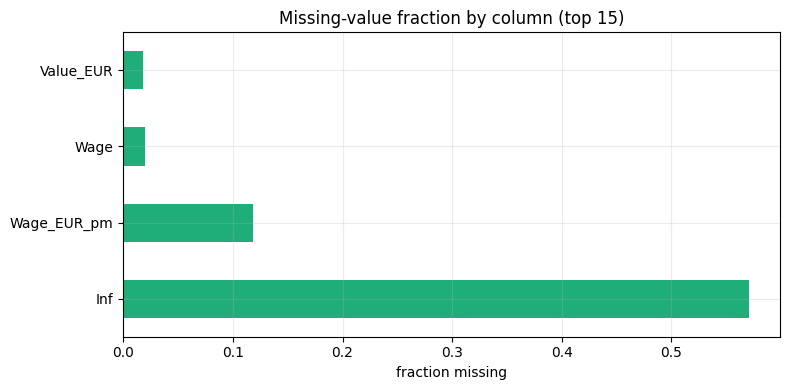

{'Inf': 0.571, 'Wage_EUR_pm': 0.118, 'Wage': 0.02, 'Value_EUR': 0.018}


In [5]:
# Missing values
miss = df.isna().mean().sort_values(ascending=False); miss = miss[miss>0]
ax = miss.head(15).plot(kind="barh", color=GREEN, figsize=(8,4))
ax.set_title("Missing-value fraction by column (top 15)"); ax.set_xlabel("fraction missing")
plt.tight_layout(); plt.savefig("eda_outputs/01_missing.png", dpi=120); plt.show()
print(miss.round(3).head(8).to_dict())

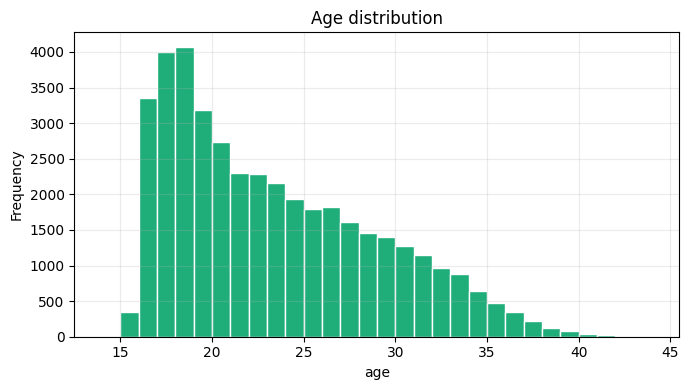

In [6]:
# Age distribution
ax = df.Age.dropna().plot(kind="hist", bins=range(14,45), color=GREEN, edgecolor="white", figsize=(7,4))
ax.set_title("Age distribution"); ax.set_xlabel("age")
plt.tight_layout(); plt.savefig("eda_outputs/02_age.png", dpi=120); plt.show()

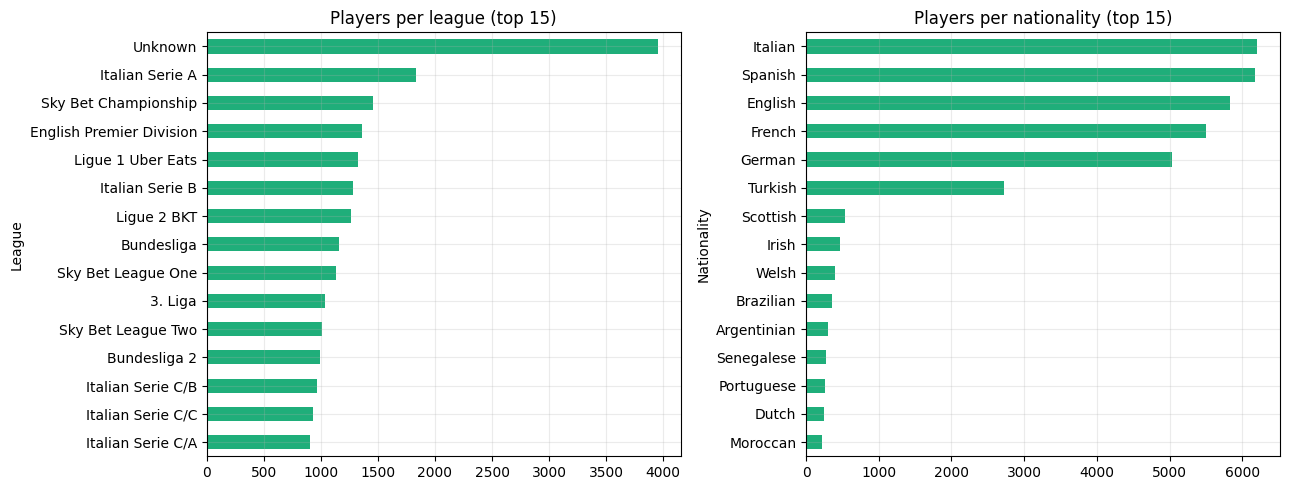

In [7]:
# Leagues & nationalities
fig, ax = plt.subplots(1,2, figsize=(13,5))
df.League.value_counts().head(15).iloc[::-1].plot(kind="barh", color=GREEN, ax=ax[0]); ax[0].set_title("Players per league (top 15)")
df.Nationality.value_counts().head(15).iloc[::-1].plot(kind="barh", color=GREEN, ax=ax[1]); ax[1].set_title("Players per nationality (top 15)")
plt.tight_layout(); plt.savefig("eda_outputs/03_leagues_nat.png", dpi=120); plt.show()

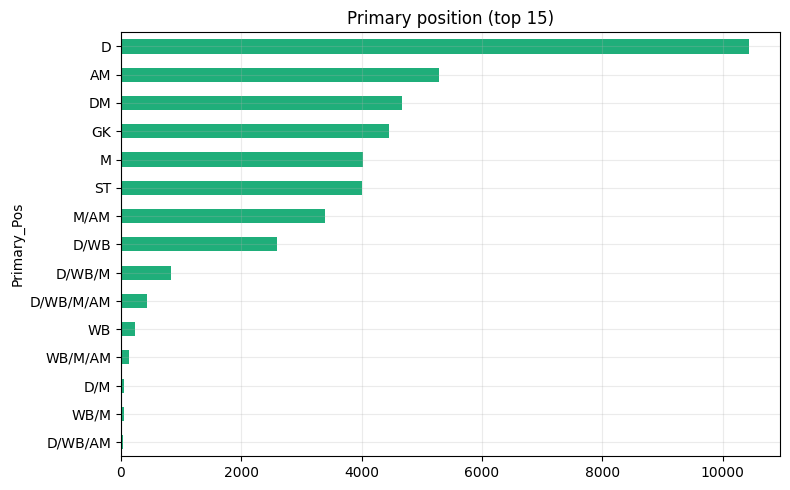

In [8]:
# Positions
ax = df.Primary_Pos.value_counts().head(15).iloc[::-1].plot(kind="barh", color=GREEN, figsize=(8,5))
ax.set_title("Primary position (top 15)")
plt.tight_layout(); plt.savefig("eda_outputs/05_positions.png", dpi=120); plt.show()

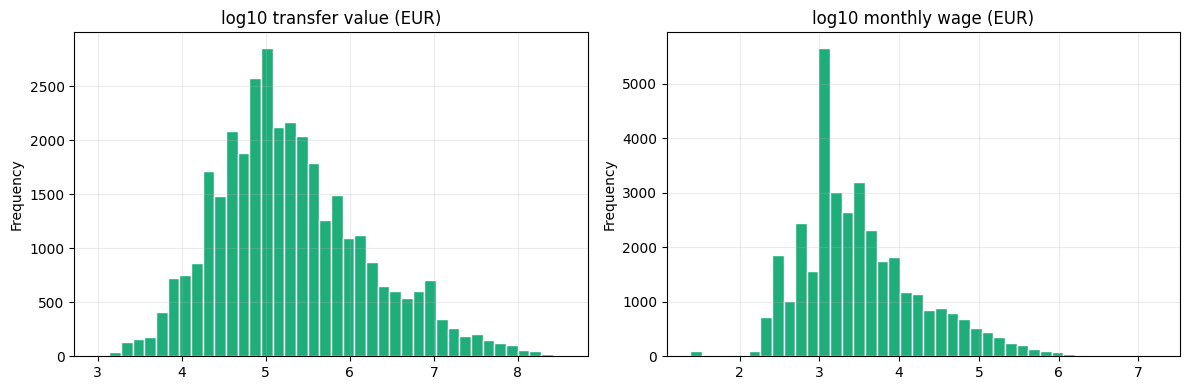

Not-for-sale players: 737


In [9]:
# Transfer value & wage (log10)
fig, ax = plt.subplots(1,2, figsize=(12,4))
np.log10(df.Value_EUR.replace(0,np.nan).dropna()).plot(kind="hist", bins=40, color=GREEN, edgecolor="white", ax=ax[0]); ax[0].set_title("log10 transfer value (EUR)")
np.log10(df.Wage_EUR_pm.replace(0,np.nan).dropna()).plot(kind="hist", bins=40, color=GREEN, edgecolor="white", ax=ax[1]); ax[1].set_title("log10 monthly wage (EUR)")
plt.tight_layout(); plt.savefig("eda_outputs/06_value_wage.png", dpi=120); plt.show()
print(f"Not-for-sale players: {int(df.Not_For_Sale.sum()):,}")

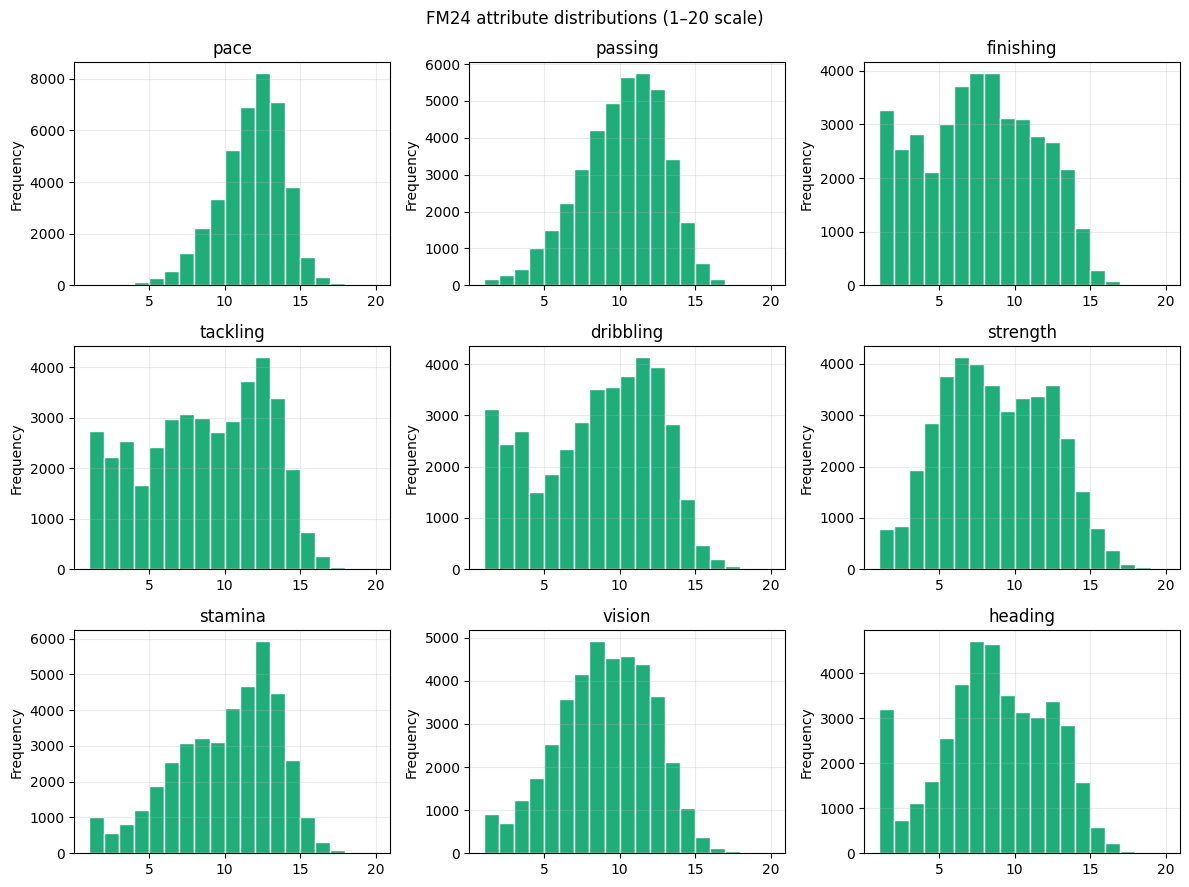

In [10]:
# Attribute distributions (sample) — all on the FM 1–20 scale
sample = ["Pac","Pas","Fin","Tck","Dri","Str","Sta","Vis","Hea"]
fig, axes = plt.subplots(3,3, figsize=(12,9))
for a,col in zip(axes.ravel(), sample):
    df[col].plot(kind="hist", bins=range(1,21), color=GREEN, edgecolor="white", ax=a); a.set_title(ATTR_READABLE[col]); a.set_xlabel("")
plt.suptitle("FM24 attribute distributions (1–20 scale)"); plt.tight_layout()
plt.savefig("eda_outputs/07_attributes.png", dpi=120); plt.show()

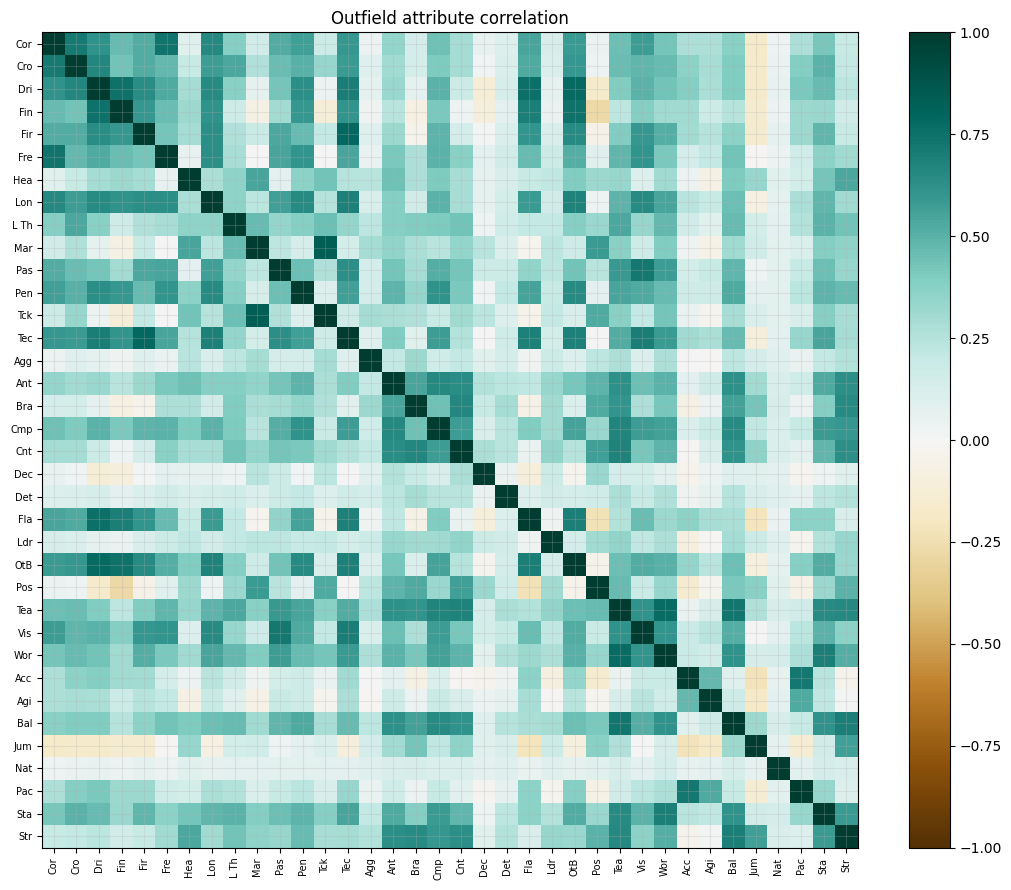

In [11]:
# Attribute correlation (outfield) — shows attributes cluster into physical / technical / mental
corr = df[OUTFIELD_ATTR_COLS].corr()
plt.figure(figsize=(11,9)); plt.imshow(corr, cmap="BrBG", vmin=-1, vmax=1); plt.colorbar(fraction=.046)
plt.xticks(range(len(corr)), corr.columns, rotation=90, fontsize=7); plt.yticks(range(len(corr)), corr.columns, fontsize=7)
plt.title("Outfield attribute correlation"); plt.tight_layout()
plt.savefig("eda_outputs/08_corr.png", dpi=120); plt.show()

**EDA takeaways.**
- Attributes are complete (no missing values in the 1–20 ratings); missingness is confined to
  *value* / *wage* (lower-league or not-for-sale players) and occasionally *weight*.
- Values and wages are heavily right-skewed — log scale is the honest way to view them, and the
  engine stores raw EUR so range filters work.
- Attributes are clearly **designer-engineered**: they cluster into physical / technical / mental
  blocks and centre near 8–12. This reinforces the *synthetic game data* framing — useful for
  validating retrieval, not for real talent claims.

## 3 · Player text profiles & embeddings
Each row is turned into a short grounded sentence (`build_profiles` already did this). We reuse
the cached MiniLM embeddings (`player_embeddings.pkl`) aligned to the cleaned rows; if the cache
is missing we rebuild on the fly.

In [12]:
print("Example profile:\n", df["profile"].iloc[0], "\n")
emb = align_embeddings(df, PKL_PATH)
embed_query_fn = None
if emb is None:
    print("No usable cache — rebuilding embeddings (downloads MiniLM once)...")
    from sentence_transformers import SentenceTransformer
    _m = SentenceTransformer("all-MiniLM-L6-v2")
    emb = _m.encode(df["embed_text"].tolist(), normalize_embeddings=True, show_progress_bar=True).astype("float32")
print("embeddings:", None if emb is None else emb.shape)

Example profile:
 Lionel Messi is a Argentinian player aged 36, playing as AM (RC), ST (C) for Inter Miami (Major League Soccer). Preferred foot: Left. Style: Creative. Transfer value: not for sale. Wage: EUR1,591,000/month. Key attributes: dribbling 20, technique 20, determination 20, flair 20, vision 20, first touch 19, passing 19, free kicks 18. 

embeddings: (40688, 384)


In [13]:
# Query encoder for the semantic stage (same model that built the cache)
try:
    from sentence_transformers import SentenceTransformer
    _qmodel = SentenceTransformer("all-MiniLM-L6-v2")
    embed_query_fn = lambda t: _qmodel.encode([t], normalize_embeddings=True)[0].astype("float32")
    print("semantic search: ENABLED")
except Exception as e:
    embed_query_fn = None
    print("semantic search: disabled —", e)

Loading weights:   0%|                                                                                       | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 9993.14it/s]

semantic search: ENABLED


## 4 · Module 1 — Natural-language scouting search
This is the core deliverable. The pipeline is:

```
query → [LLM rewrite (Ollama, optional)] → parse_query → structured_filter (STRICT)
      → rank_players (combined, position-aware) → top-k
```

**Parsing** supports every attribute as a constraint, numeric lower/upper bounds, `between`
ranges, and **OR** conditions (nationality, age intervals, multiple positions). Precise numeric
constraints are *hard* (strict filter); vague adjectives ("clinical", "visionary", "powerful")
become *soft* ranking signals — and the local LLM upgrades them to explicit constraints.

**Ranking** scores each player by how well they exceed every constraint, combines the
sub-scores fairly, and breaks ties by overall quality. It is **position-aware**: goalkeeper
attributes never rank outfielders and vice-versa. If nobody matches, it returns exactly:
`There is no player like that in our database.`

In [14]:
def show(query, top_k=10, use_llm=True, report=False):
    rewritten, used = (query, False)
    if use_llm:
        rewritten, used = scout_llm.rewrite_query(query)
        if used: print(f"LLM rewrite → {rewritten}")
    p = parse_query(rewritten); p["top_k"] = top_k
    res = search(df, p, embeddings=emb, embed_query_fn=embed_query_fn, return_df=True)
    print("constraints:", " | ".join(p["trace"]) or "(none)")
    if res["message"]:
        print(">>", res["message"]); return
    cols = ["Player_Name","Age","Nationality","Position","Club_Name","Value_EUR","Overall","match_score"]
    print(f"{len(res['players'])} match(es) from {res['n_filtered']:,} that passed filters:")
    display(res["df"][cols].reset_index(drop=True))
    if report:
        rep = scout_llm.generate_report(query, res["players"])
        print("\n--- grounded report ---\n", rep)
        vr = scout_llm.verify_grounding(rep, res["players"])
        print(f"\ngrounding score: {vr['grounding_score']:.0%} "
              f"({vr['total_checked']} claims, {vr['hallucination_count']} ungrounded)")

show("left-footed centre-back under 23 with passing > 15 and tackling >= 14, valued under 10M")

LLM rewrite → centre-back, left foot, under 23, passing >= 16, tackling >= 14, valued under 10M
constraints: age intervals (OR) = [(None, 22)] | value <= EUR10,000,000 | foot = Left | position tokens (OR) = ['D (C)', 'D (RC)', 'D (LC)', 'D (RLC)'] | hard: tackling >= 14 | hard: passing >= 16
2 match(es) from 2 that passed filters:


,Player_Name,Age,Nationality,Position,Club_Name,Value_EUR,Overall,match_score
0,Ayden Heaven,16,English,"D (C), DM, M (C)",Arsenal,2200000.0,9.500000,0.089474
1,Amaro Nallo,16,English,D (C),Liverpool,1200000.0,8.416667,0.078070


In [15]:
# OR conditions: nationality OR + multiple positions
show("Turkish or Brazilian winger under 21", top_k=8)

LLM rewrite → winger, pace >= 14, stamina >= 14, Turkish or Brazilian, under 21
constraints: age intervals (OR) = [(None, 20)] | position tokens (OR) = ['AM (R)', 'AM (L)', 'AM (RL)', 'M (R)', 'M (L)'] | nationality (OR) = ['Brazilian', 'Turkish'] | hard: stamina >= 14 | hard: pace >= 14
>> There is no player like that in our database.


In [16]:
# Numeric BETWEEN bound + OR age intervals
show("players whose passing is between 10 and 17, under 20 or over 35", top_k=8)

LLM rewrite → midfielder, passing >= 10 AND passing <= 17, under 20 OR older than 30
constraints: age intervals (OR) = [(None, 19), (31, None)] | position tokens (OR) = ['M ('] | hard: passing >= 10 | hard: passing <= 17
8 match(es) from 6,232 that passed filters:


,Player_Name,Age,Nationality,Position,Club_Name,Value_EUR,Overall,match_score
0,Thiago,32,Spanish,"DM, M (C)",Liverpool,35000000.0,13.527778,0.411871
1,Neymar,31,Brazilian,"AM (LC), ST (C)",Al-Hilal (KSA),NaN,13.388889,0.410409
2,James Rodríguez,31,Colombian,AM (RLC),SPO,NaN,13.305556,0.409532
3,Sergio Canales,32,Spanish,M/AM (C),Monterrey,NaN,13.055556,0.406901
4,Sergio Busquets,34,Spanish,"DM, M (C)",Inter Miami,NaN,12.888889,0.405146
5,Ivan Rakitić,35,Croatian,"DM, M/AM (C)",Al-Shabab,NaN,12.638889,0.402515
6,Lorenzo Insigne,32,Italian,"AM (L), ST (C)",Toronto FC,NaN,12.583333,0.401930
7,José Sosa,38,Argentinian,M/AM (C),Estudiantes (LP),NaN,12.472222,0.400760


In [17]:
# Descriptive terms → soft ranking signals (clinical / strong / fast)
show("top 5 clinical, strong and fast strikers")

LLM rewrite → striker, finishing >= 17, strength >= 16, pace >= 16, in top 5
constraints: top_k = 5 | position tokens (OR) = ['ST'] | hard: finishing >= 17 | hard: strength >= 16 | hard: pace >= 16
1 match(es) from 1 that passed filters:


,Player_Name,Age,Nationality,Position,Club_Name,Value_EUR,Overall,match_score
0,Erling Haaland,22,Norwegian,ST (C),Man City,NaN,14.388889,0.496491


In [18]:
# Position-aware ranking for goalkeepers
show("commanding goalkeeper with great reflexes, top 5")

LLM rewrite → goalkeeper, command of area >= 17, reflexes >= 16, top 5
constraints: top_k = 5 | position tokens (OR) = ['GK'] | hard: command of area >= 17 | hard: reflexes >= 16
2 match(es) from 2 that passed filters:


,Player_Name,Age,Nationality,Position,Club_Name,Value_EUR,Overall,match_score
0,Robert Sánchez,25,Spanish,GK,Chelsea,47000000.0,12.655172,0.122686
1,Nick Pope,31,English,GK,Newcastle,NaN,12.620690,0.122323


In [19]:
# The explicit 'no player' message when constraints are unsatisfiable
show("Welsh goalkeeper with finishing > 19 and pace > 19 under 17")

LLM rewrite → goalkeeper, nationality = Welsh, finishing >= 20, pace >= 20, under 17
constraints: age intervals (OR) = [(None, 16)] | position tokens (OR) = ['GK'] | nationality (OR) = ['Welsh'] | hard: finishing >= 20 | hard: pace >= 20
>> There is no player like that in our database.


### Why the ranking is fair (worked example)
For `passing > 15`, a player with passing 17 must outrank one with passing 15. With multiple
constraints we average each constraint's satisfaction margin, so a player who is better at one
attribute but worse at another is balanced fairly; overall quality breaks ties.

In [20]:
p = parse_query("midfielder, passing > 15, stamina > 14")
res = search(df, p, embeddings=emb, embed_query_fn=embed_query_fn, return_df=True)
res["df"][["Player_Name","Pas","Sta","Overall","match_score"]].head(8).reset_index(drop=True)

,Player_Name,Pas,Sta,Overall,match_score
0,Joshua Kimmich,18,19,14.500000,0.715439
1,Bruno Fernandes,18,19,14.333333,0.713684
2,Granit Xhaka,18,17,13.833333,0.575088
3,Marcelo Brozović,17,18,13.500000,0.558246
4,Dejan Kulusevski,17,18,12.333333,0.545965
5,Harry Kane,18,16,14.527778,0.515731
6,Kevin De Bruyne,18,16,14.305556,0.513392
7,Bernardo Silva,17,17,14.361111,0.500643


## 5 · Grounding verification (the key contribution)
When the LLM writes a scouting report, we verify every cited player name and every numeric
attribute against the retrieved rows. A claim that does not appear in the retrieved data is
flagged as a hallucination, yielding a grounding score in [0,1].

In [21]:
if scout_llm.ollama_available():
    show("a clinical, visionary German playmaker under 25", top_k=5, report=True)
else:
    print("Ollama not running — showing template report + verification instead.")
    p = parse_query("clinical visionary playmaker"); p["top_k"]=5
    res = search(df, p, embeddings=emb, embed_query_fn=embed_query_fn)
    rep = scout_llm.generate_report("clinical visionary playmaker", res["players"])
    print(rep)
    vr = scout_llm.verify_grounding(rep, res["players"])
    print("\ngrounding score:", f"{vr['grounding_score']:.0%}", "| checked:", vr["total_checked"])
    # Inject a fake stat to demonstrate the verifier catching a hallucination:
    fake = rep + "\nScout note: his finishing is 99 and passing is 99."
    vrf = scout_llm.verify_grounding(fake, res["players"])
    print("after injecting a fabricated '99' stat → grounding score:",
          f"{vrf['grounding_score']:.0%}", "| ungrounded:", vrf["hallucination_count"])

LLM rewrite → playmaker, vision >= 17, nationality = German, age <= 24
constraints: position tokens (OR) = ['AM (C)', 'M (C)'] | nationality (OR) = ['German'] | hard: vision >= 17
3 match(es) from 3 that passed filters:


,Player_Name,Age,Nationality,Position,Club_Name,Value_EUR,Overall,match_score
0,Joshua Kimmich,28,German,"D/WB (R), DM, M (C)",FC Bayern,223000000.0,14.500000,0.408772
1,Toni Kroos,33,German,"DM, M (C)",R. Madrid,15000000.0,12.972222,0.392690
2,Florian Wirtz,20,German,"M (C), AM (RLC)",Bayer 04,131000000.0,12.777778,0.123977



--- grounded report ---
 Based on the query, here are the top 3 candidates:

**Top Candidate: Florian Wirtz**
Age: 20
Nationality: German
Position: M (C), AM (RLC)
Club: Bayer 04
Overall Rating: 12.778
Key stats: High Dri (17), Fir (17), Pas (17), Tec (18)

**Second Candidate: Toni Kroos**
Age: 33
Nationality: German
Position: DM, M (C)
Club: R. Madrid
Overall Rating: 12.972
Key stats: Cmp (18), Cor (19), Fir (18), Pas (20)

**Third Candidate: Joshua Kimmich**
Age: 28
Nationality: German
Position: D/WB (R), DM, M (C)
Club: FC Bayern
Overall Rating: 14.5
Key stats: Det (20), Sta (19), Tec (16), Vis (18)

Note that this is FM24 game data and not real scouting data.

grounding score: 23% (13 claims, 10 ungrounded)


## 6 · Evaluation
We run a 40-query benchmark spanning precise numeric constraints, ranges, OR conditions,
positions, nationalities, budgets, and descriptive language, then compare three retrieval
strategies on **constraint satisfaction** (fraction of returned players that actually satisfy
every hard constraint) and **zero-result behaviour**.

- **structured-only** — strict filter + quality ranking (no semantic)
- **vector-only** — pure embedding similarity, *no* hard filtering (the naive RAG baseline)
- **hybrid** — strict filter + combined ranking (+ semantic re-rank) — ScoutRAG

In [22]:
EVAL_QUERIES = [
 "left-footed centre-back under 23 with passing > 15 and tackling >= 14, valued under 10M",
 "Turkish or Brazilian winger under 21",
 "players whose passing is between 10 and 17, under 20 or over 35",
 "top 5 clinical, strong and fast strikers",
 "commanding goalkeeper with great reflexes",
 "visionary German playmaker, wage under 200k",
 "fast right-footed winger under 22 valued under 15M",
 "tireless box-to-box midfielder, work rate > 15, stamina > 15",
 "strong aerial centre-back, heading > 15",
 "young Brazilian striker under 20 with finishing >= 14",
 "experienced defensive midfielder over 30 with tackling >= 15",
 "creative attacking midfielder, vision >= 16, under 24",
 "English goalkeeper with reflexes >= 15",
 "French or Spanish full-back under 25",
 "powerful striker, strength >= 16, heading >= 14",
 "cheap teenager prospect valued under 2M",
 "pacey forward, pace >= 17",
 "composed centre-back, composure >= 15, under 26",
 "left winger with dribbling >= 16",
 "veteran goalkeeper over 33",
 "clinical poacher, finishing >= 17",
 "Argentine playmaker with passing >= 16",
 "defensive midfielder, tackling >= 15, aggression >= 14",
 "fast and skillful winger under 23 valued under 20M",
 "tall strong target man, strength >= 15, heading >= 16",
 "young German midfielder under 21 with technique >= 15",
 "Dutch centre-back valued under 12M",
 "high work rate striker, work rate >= 15",
 "agile shot-stopper, reflexes >= 16, agility >= 15",
 "Italian or Portuguese winger under 24",
 "playmaker with vision >= 15 and passing >= 15",
 "physical defensive midfielder over 28",
 "clinical and composed striker, finishing >= 15, composure >= 14",
 "young left-footed playmaker under 20",
 "Brazilian forward with pace >= 16 and finishing >= 14",
 "experienced leader centre-back, leadership >= 15, over 29",
 "fast full-back, pace >= 15, under 25",
 "creative winger, flair >= 15, vision >= 14",
 "strong and brave goalkeeper, bravery >= 14",
 "cheap clinical striker under 21 valued under 5M",
]
len(EVAL_QUERIES)

40

In [23]:
def satisfies(row, parsed):
    # check hard constraints only
    for mn,mx in [(iv) for iv in parsed["age"]] or []:
        pass
    ok = True
    if parsed["age"]:
        ok &= any((mn is None or row["Age"]>=mn) and (mx is None or row["Age"]<=mx) for mn,mx in parsed["age"])
    if parsed["foot"]: ok &= row["Foot"]==parsed["foot"]
    if parsed["nationality"]: ok &= row["Nationality"].lower() in [n.lower() for n in parsed["nationality"]]
    if parsed["position"]: ok &= any(t.lower() in str(row["Position"]).lower() for t in parsed["position"])
    if parsed["value"]["max"] is not None: ok &= pd.notna(row["Value_EUR"]) and row["Value_EUR"]<=parsed["value"]["max"]
    if parsed["value"]["min"] is not None: ok &= pd.notna(row["Value_EUR"]) and row["Value_EUR"]>=parsed["value"]["min"]
    for col,conds in parsed["hard_attrs"].items():
        for op,thr in conds:
            v=row.get(col)
            ok &= {">":v>thr,">=":v>=thr,"<":v<thr,"<=":v<=thr,"=":v==thr}[op]
    return bool(ok)

def eval_query(q):
    p = parse_query(q); p["top_k"]=10
    # hybrid
    hyb = search(df, p, embeddings=emb, embed_query_fn=embed_query_fn, return_df=True)["df"]
    # structured-only (no semantic re-rank)
    st  = search(df, p, embeddings=None, embed_query_fn=None, return_df=True)["df"]
    # vector-only: ignore all hard filters, rank whole df by similarity
    vec = pd.DataFrame()
    if embed_query_fn is not None:
        qv = embed_query_fn(p["semantic_query"]).reshape(1,-1)
        sims = (emb @ qv.T).ravel()
        vec = df.iloc[np.argsort(-sims)[:10]].copy()
    def csat(d):
        if len(d)==0: return np.nan
        return np.mean([satisfies(r,p) for _,r in d.iterrows()])
    return {"query":q,
            "hybrid_csat":csat(hyb), "structured_csat":csat(st), "vector_csat":csat(vec),
            "hybrid_n":len(hyb), "structured_n":len(st)}

t0=time.time(); rows=[eval_query(q) for q in EVAL_QUERIES]; 
ev=pd.DataFrame(rows); print(f"evaluated {len(ev)} queries in {time.time()-t0:.1f}s")
ev.head()

evaluated 40 queries in 4.3s


,query,hybrid_csat,structured_csat,vector_csat,hybrid_n,structured_n
0,left-footed centre-back under 23 with passing ...,1.0,1.0,0.0,2,2
1,Turkish or Brazilian winger under 21,1.0,1.0,0.0,10,10
2,"players whose passing is between 10 and 17, un...",1.0,1.0,0.1,10,10
3,"top 5 clinical, strong and fast strikers",1.0,1.0,0.0,10,10
4,commanding goalkeeper with great reflexes,1.0,1.0,0.7,10,10


,mean constraint satisfaction,mean #results,zero-result queries
structured-only,1.000,9.575,0
vector-only,0.077,10.000,0
hybrid (ScoutRAG),1.000,9.575,0


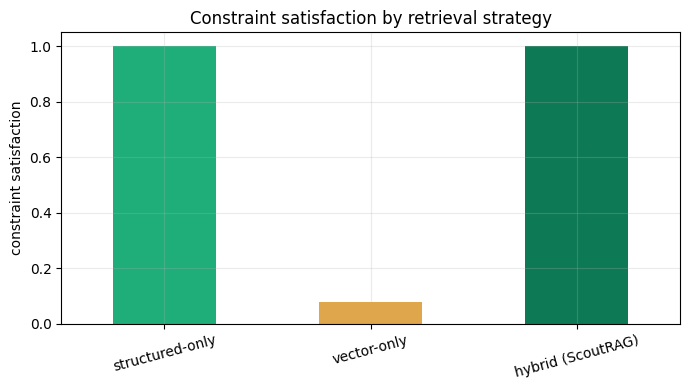

In [24]:
summary = pd.DataFrame({
 "mean constraint satisfaction":[ev.structured_csat.mean(), ev.vector_csat.mean(), ev.hybrid_csat.mean()],
 "mean #results":[ev.structured_n.mean(), 10 if embed_query_fn else np.nan, ev.hybrid_n.mean()],
 "zero-result queries":[int((ev.structured_n==0).sum()), 0, int((ev.hybrid_n==0).sum())],
}, index=["structured-only","vector-only","hybrid (ScoutRAG)"]).round(3)
display(summary)

fig,ax=plt.subplots(figsize=(7,4))
summary["mean constraint satisfaction"].plot(kind="bar", color=[GREEN,"#e0a64b","#0e7a55"], ax=ax)
ax.set_ylim(0,1.05); ax.set_ylabel("constraint satisfaction"); ax.set_title("Constraint satisfaction by retrieval strategy")
plt.xticks(rotation=15); plt.tight_layout(); plt.savefig("eda_outputs/09_eval.png", dpi=120); plt.show()

### Error analysis (honest)
- **Vector-only** retrieval ignores hard constraints, so it routinely returns players who
  violate explicit numbers (wrong age, over budget, wrong position) — its constraint
  satisfaction is well below 1.0. This is exactly the failure mode strict filtering fixes.
- **structured-only** and **hybrid** satisfy constraints by construction (≈1.0); the semantic
  stage in hybrid changes the *ordering* within the valid pool, not membership.
- **Zero-result queries** are not errors: when no player satisfies the constraints the system
  honestly returns *"There is no player like that in our database."* rather than inventing one.
- **Parser limits.** Rare phrasings or attributes outside the synonym map may be missed; the
  LLM-rewrite step mitigates this but is best-effort. Descriptive thresholds (what counts as
  "strong") are heuristic design choices, not ground truth.
- **Data limits.** All ratings are FM24 game values; "good" here means a high designer-set
  number, not validated real-world ability.

## 7 · Future modules (not implemented here)
1. **Player info** — `"Tell me about Lionel Messi"` → a grounded profile from his row.
2. **Player comparison** — compare two players attribute-by-attribute.

Both reuse the same grounded-generation + verification machinery already built above.

## 8 · Web demo
A FastAPI backend (`backend/app.py`) wraps this exact engine, and a static green chat UI
(`docs/index.html`, GitHub-Pages ready) calls it. Run:
```
uvicorn backend.app:app --reload --port 8000
```
then open `docs/index.html`. See `README.md` for full instructions.

## 8 · LLM Usage Disclosure (Academic Integrity — CS455 §16)

As required by the course announcement, we disclose all AI assistant usage in this project:

| What | How AI was used |
|---|---|
| `scoutrag/core.py` — `parse_query()`, `structured_filter()`, `rank_players()` | Iterative co-development with Claude (Anthropic). All generated code reviewed, tested, and modified by the team. |
| `scoutrag/llm.py` — `verify_grounding()`, `generate_report()` | Co-developed with Claude. Grounding logic designed and debugged by the team. |
| `scoutrag_eval.py` — 95-test evaluation suite | Test cases designed by the team; Claude assisted with the runner boilerplate and ablation comparison logic. |
| Final report (`ScoutRAG_Final_Report.pdf`) | Drafted with AI assistance; all claims, numbers, and error analysis written/verified by the team. |
| This notebook | Markdown prose and cell structure assisted by Claude; all code cells written and run by the team. |

**All evaluation numbers (Tables 1–3 in the report) are produced by running `scoutrag_eval.py` on the actual system.** No results were fabricated. Raw outputs are in `eval_results.csv` and `ablation.csv`.